# Judge comparison — gpt-4o vs gpt-4o-mini as the Self-RAG claim-verification judge

**Date:** 2026-06-02

**Goal:** Hold the claim set and contexts fixed; vary only the verifier model. Quantify per-claim agreement, support-rate delta, disagreement asymmetry, and the cost/latency differential between the two judges as Self-RAG verifiers.

**What this notebook does NOT do:**
- It does not claim that either judge is "more accurate" or "correct."
- It does not treat either judge's verdicts as ground truth.
- It does not hand-annotate claims.

No faithfulness gold labels exist for this corpus (FiQA labels are doc-level retrieval relevance only). All metrics below are therefore agreement / disagreement metrics between two model judges, not accuracy metrics.

## Design — frozen-claim verification-only replay

**Variable:** the verifier model.
**Fixed:** the claim set, the retrieved contexts, the claim-decomposition step, the answer-generation model.

**Source of frozen inputs:** `evaluation/results/self_rag_fiqa_2026-05-05_gpt4o-mini.json` — the existing Self-RAG benchmark run.

Per query, the frozen claim list is `self_rag_stats.verified_claims + self_rag_stats.unsupported_claims` (in that order). Join key for all analysis is `(query_id, claim_index)` where `claim_index` is the position in that concatenated list. We do **not** re-extract claims — extraction is the confound we are eliminating, and re-extracting would give the two judges different claim sets and make agreement / kappa undefined.

**Verifier reuse:** we call `SelfRAGGenerator._verify_claim(claim, context, llm_service)` from `generation/advanced_generation.py` directly, with a minimal LLM-service shim. This guarantees both judges see the production verification prompt, production context truncation (`context[:3000]`), production markdown-fence stripping, production positive-whitelist support detection, and production fail-closed parse error handling. We are not reimplementing any of those.

**Honest framing of the frozen claims:** the claims were extracted by gpt-4o-mini in the 5-05 run. So the comparison question is "**given that decomposition, how do the two judges verify it.**" Not "how would each judge extract claims," which is a separate experiment with a different join structure.

In [1]:
from __future__ import annotations

import asyncio
import json
import os
import sys
import time
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "orchestrator.py").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "orchestrator.py").exists(), f"repo root not found from {Path.cwd()}"
sys.path.insert(0, str(REPO_ROOT))

SOURCE_RUN = REPO_ROOT / "evaluation" / "results" / "self_rag_fiqa_2026-05-05_gpt4o-mini.json"
OUT_JSON   = REPO_ROOT / "evaluation" / "results" / "judge_comparison_2026-06-02.json"
PLOTS_DIR  = REPO_ROOT / "evaluation" / "results"

print("repo root :", REPO_ROOT)
print("source run:", SOURCE_RUN.name, "exists" if SOURCE_RUN.exists() else "MISSING")

repo root : /Users/hemakollipara/Desktop/ragcore
source run: self_rag_fiqa_2026-05-05_gpt4o-mini.json exists


In [2]:
# Load the frozen source run and build the per-claim replay queue.
with open(SOURCE_RUN) as f:
    src = json.load(f)

src_metadata = src["metadata"]
records = src["results"]
print("source metadata:", json.dumps(src_metadata, indent=2))
print("n source records:", len(records))

frozen = []
for r in records:
    qid = r["query_id"]
    contexts: list[str] = r.get("retrieved_contexts", []) or []
    # Production builds the verification context by joining retrieved chunks
    # with "\n\n" before passing into _verify_claim, which then truncates
    # to context[:3000]. We do the join here; truncation happens inside
    # _verify_claim (we let production do it, not the replay).
    context_str = "\n\n".join(contexts)
    stats = r.get("self_rag_stats", {}) or {}
    claims = list(stats.get("verified_claims", [])) + list(stats.get("unsupported_claims", []))
    if not claims:
        continue
    frozen.append({
        "query_id": qid,
        "query": r.get("query", ""),
        "generated_answer": r.get("generated_answer", ""),
        "context_str": context_str,
        "claims": claims,
        "stored_5_05_verdicts": (
            [1] * len(stats.get("verified_claims", []))
            + [0] * len(stats.get("unsupported_claims", []))
        ),
        "stored_ragas_faithfulness": r.get("ragas_faithfulness"),
    })

n_queries = len(frozen)
n_claims = sum(len(f["claims"]) for f in frozen)
print(f"frozen queries: {n_queries}")
print(f"frozen claims : {n_claims}")
print(f"claims/query  : {n_claims / n_queries:.2f}")

source metadata: {
  "run_timestamp_utc": "2026-05-06T21:33:09.353183Z",
  "llm_provider": "openai",
  "llm_model": "gpt-4o-mini",
  "vector_store_provider": "faiss",
  "embedding_provider": "bge",
  "eval_strategy": "heuristic",
  "generation_strategy": "self_rag",
  "ragas_judge": "gpt-4o-mini",
  "dataset": "fiqa_eval",
  "dataset_size": 50
}
n source records: 50
frozen queries: 38
frozen claims : 181
claims/query  : 4.76


## Judge shim

A minimal `llm_service`-compatible object that `_verify_claim` can consume. It exposes the single `generate(query, prompt, query_type, strategy_used)` method that `_verify_claim` actually calls, forwards `prompt.messages` to OpenAI's chat completion API at a configurable model, and side-channels per-call tokens + latency for the replay loop to collect.

In [3]:
from openai import AsyncOpenAI

@dataclass
class _ShimResult:
    """Mimics the GenerationResult interface that _verify_claim reads (.answer)."""
    answer: str

class JudgeShim:
    """Minimal llm_service shim for SelfRAGGenerator._verify_claim.

    Captures per-call input_tokens / output_tokens / latency_ms / raw_response
    on instance attributes so the replay loop can read them after each call.
    """

    def __init__(self, model: str, api_key: str, temperature: float = 0.0, max_tokens: int = 512):
        self.model = model
        self._client = AsyncOpenAI(api_key=api_key)
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.last_input_tokens = 0
        self.last_output_tokens = 0
        self.last_latency_ms = 0.0
        self.last_raw_response = ""

    async def generate(self, *, query, prompt, query_type, strategy_used):
        t0 = time.monotonic()
        resp = await self._client.chat.completions.create(
            model=self.model,
            messages=prompt.messages,
            temperature=self.temperature,
            max_tokens=self.max_tokens,
        )
        self.last_latency_ms = (time.monotonic() - t0) * 1000.0
        answer = resp.choices[0].message.content or ""
        usage = resp.usage
        self.last_input_tokens = usage.prompt_tokens if usage else 0
        self.last_output_tokens = usage.completion_tokens if usage else 0
        self.last_raw_response = answer
        return _ShimResult(answer=answer)


# Read API key from project .env or environment
def _read_openai_key() -> str:
    if os.environ.get("OPENAI_API_KEY"):
        return os.environ["OPENAI_API_KEY"]
    env_path = REPO_ROOT / ".env"
    if env_path.exists():
        for line in env_path.read_text().splitlines():
            line = line.strip()
            if line.startswith("OPENAI_API_KEY="):
                return line.split("=", 1)[1].strip().strip('"').strip("'")
    raise RuntimeError("OPENAI_API_KEY not found in env or .env")

API_KEY = _read_openai_key()
print("API key loaded:", "yes" if API_KEY else "no", "len=", len(API_KEY))

API key loaded: yes len= 164


## Replay loop

For each (query_id, claim_index) in the frozen set, call `_verify_claim` once with the gpt-4o shim and once with the gpt-4o-mini shim. Two API calls per claim × 181 claims = 362 verifier calls per full run. The shims run sequentially (no concurrency) — within-judge ordering keeps token accounting clean and avoids burst-rate failures on Groq-style providers (not relevant for OpenAI, but cheap insurance).

In [4]:
from generation.advanced_generation import SelfRAGGenerator

# We reuse _verify_claim as-is. Construct one SelfRAGGenerator instance — it
# doesn't matter which model the constructor "thinks" it uses, because the
# llm_service is injected per-call via the shim.
verifier = SelfRAGGenerator()

shim_4o   = JudgeShim(model="gpt-4o",      api_key=API_KEY)
shim_mini = JudgeShim(model="gpt-4o-mini", api_key=API_KEY)


async def _run_one(claim: str, context: str, shim: JudgeShim) -> dict:
    supported, evidence = await verifier._verify_claim(claim, context, shim)
    return {
        "supported": bool(supported),
        "evidence": evidence,
        "raw_response": shim.last_raw_response,
        "input_tokens": shim.last_input_tokens,
        "output_tokens": shim.last_output_tokens,
        "latency_ms": round(shim.last_latency_ms, 1),
    }


async def replay_all() -> list[dict]:
    per_claim = []
    total = sum(len(f["claims"]) for f in frozen)
    seen = 0
    wall0 = time.monotonic()
    for q_idx, item in enumerate(frozen):
        qid = item["query_id"]
        ctx = item["context_str"]
        for c_idx, claim in enumerate(item["claims"]):
            r_4o   = await _run_one(claim, ctx, shim_4o)
            r_mini = await _run_one(claim, ctx, shim_mini)
            per_claim.append({
                "query_id": qid,
                "query_idx": q_idx,
                "claim_index": c_idx,
                "claim": claim,
                "stored_5_05_verdict": item["stored_5_05_verdicts"][c_idx],
                "gpt_4o": r_4o,
                "gpt_4o_mini": r_mini,
            })
            seen += 1
            if seen % 25 == 0 or seen == total:
                elapsed = time.monotonic() - wall0
                rate = seen / elapsed if elapsed > 0 else 0
                eta = (total - seen) / rate if rate > 0 else 0
                print(f"  [{seen:>3}/{total}] elapsed={elapsed:6.1f}s rate={rate:4.2f}/s eta={eta:5.1f}s")
    return per_claim


per_claim_records = await replay_all()
print(f"DONE — {len(per_claim_records)} claim-level records")

  [ 25/181] elapsed=  42.7s rate=0.59/s eta=266.5s


  [ 50/181] elapsed=  80.1s rate=0.62/s eta=210.0s


  [ 75/181] elapsed= 120.1s rate=0.62/s eta=169.7s


  [100/181] elapsed= 156.5s rate=0.64/s eta=126.8s


  [125/181] elapsed= 197.6s rate=0.63/s eta= 88.5s


  [150/181] elapsed= 239.7s rate=0.63/s eta= 49.5s


  [175/181] elapsed= 281.0s rate=0.62/s eta=  9.6s


  [181/181] elapsed= 291.8s rate=0.62/s eta=  0.0s
DONE — 181 claim-level records


## Persist comparison JSON

`evaluation/results/judge_comparison_2026-06-02.json` — keyed by `(query_id, claim_index)`. Metadata explicitly distinguishes what is **fixed** (answer-gen model, extractor model, source run) from what is **varied** (judge model). This fixes the audit finding that the existing benchmark metadata could not distinguish "judge model" from "answer-gen model" — they were collapsed into one `llm_model` field.

In [5]:
out_metadata = {
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "experiment": "self_rag_judge_comparison",
    "source_run": SOURCE_RUN.name,
    "answer_gen_model":   src_metadata.get("llm_model"),
    "claim_extractor_model": src_metadata.get("llm_model"),
    "judge_models": ["gpt-4o", "gpt-4o-mini"],
    "judge_temperature": 0.0,
    "verifier_function": "generation.advanced_generation.SelfRAGGenerator._verify_claim",
    "context_truncation_chars": 3000,
    "n_queries": n_queries,
    "n_claims": n_claims,
    "dataset": src_metadata.get("dataset"),
    "dataset_size": src_metadata.get("dataset_size"),
    "notes": (
        "Frozen-claim verification-only replay. Claim set and contexts are held "
        "fixed; only the verifier model varies. No gold labels — agreement and "
        "support-rate are judge-vs-judge metrics, not accuracy metrics."
    ),
}

out_payload = {
    "metadata": out_metadata,
    "results": per_claim_records,
}

OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_JSON, "w") as f:
    json.dump(out_payload, f, indent=2)

print("wrote", OUT_JSON)
print("size :", OUT_JSON.stat().st_size, "bytes")

wrote /Users/hemakollipara/Desktop/ragcore/evaluation/results/judge_comparison_2026-06-02.json
size : 171156 bytes


## Metrics

All metrics are computed from the comparison JSON we just wrote. Re-loading from disk so this section is self-contained and can be re-run without redoing the (expensive) replay.

In [6]:
# Reload from disk so the metrics section is independent of the replay loop.
with open(OUT_JSON) as f:
    artifact = json.load(f)

records = artifact["results"]

df = pd.DataFrame([
    {
        "query_id": r["query_id"],
        "query_idx": r["query_idx"],
        "claim_index": r["claim_index"],
        "claim": r["claim"],
        "stored_5_05": r["stored_5_05_verdict"],
        "gpt_4o": int(r["gpt_4o"]["supported"]),
        "gpt_4o_mini": int(r["gpt_4o_mini"]["supported"]),
        "gpt_4o_in_tok":  r["gpt_4o"]["input_tokens"],
        "gpt_4o_out_tok": r["gpt_4o"]["output_tokens"],
        "gpt_4o_lat_ms":  r["gpt_4o"]["latency_ms"],
        "mini_in_tok":  r["gpt_4o_mini"]["input_tokens"],
        "mini_out_tok": r["gpt_4o_mini"]["output_tokens"],
        "mini_lat_ms":  r["gpt_4o_mini"]["latency_ms"],
        "gpt_4o_evidence": r["gpt_4o"]["evidence"],
        "mini_evidence":   r["gpt_4o_mini"]["evidence"],
    }
    for r in records
])
print("per-claim rows:", len(df))
df.head(3)

per-claim rows: 181


,query_id,query_idx,claim_index,claim,stored_5_05,gpt_4o,gpt_4o_mini,gpt_4o_in_tok,gpt_4o_out_tok,gpt_4o_lat_ms,mini_in_tok,mini_out_tok,mini_lat_ms,gpt_4o_evidence,mini_evidence
0,10385,0,0,You should start saving and investing for your...,1,1,1,266,36,2257.7,266,36,1589.1,Start as early as possible and you will want t...,Start as early as possible and you will want t...
1,10385,0,1,It's recommended to begin with whatever amount...,1,1,1,264,26,537.1,264,26,1157.0,Start with whatever you feel comfortable with ...,Start with whatever you feel comfortable with ...
2,10385,0,2,It's important to be consistent in increasing ...,1,1,1,265,29,509.3,265,29,1323.5,"Increase that amount with raises, income gains...","Increase that amount with raises, income gains..."


### 1. Per-claim verdict agreement + Cohen's kappa

In [7]:
from sklearn.metrics import cohen_kappa_score

n_total = len(df)
n_agree = int((df["gpt_4o"] == df["gpt_4o_mini"]).sum())
agreement_rate = n_agree / n_total

kappa = cohen_kappa_score(df["gpt_4o"], df["gpt_4o_mini"])

print(f"Per-claim agreement: {n_agree}/{n_total} = {agreement_rate*100:.1f}%")
print(f"Cohen's kappa     : {kappa:+.3f}")

Per-claim agreement: 150/181 = 82.9%
Cohen's kappa     : +0.663


### 2. Per-query support rate + Wilcoxon signed-rank test

In [8]:
from scipy.stats import wilcoxon

per_query = (
    df.groupby("query_id")
      .agg(
          n_claims=("claim", "count"),
          sup_4o=("gpt_4o", "sum"),
          sup_mini=("gpt_4o_mini", "sum"),
      )
      .reset_index()
)
per_query["rate_4o"]   = per_query["sup_4o"]   / per_query["n_claims"]
per_query["rate_mini"] = per_query["sup_mini"] / per_query["n_claims"]
per_query["delta"]     = per_query["rate_4o"]  - per_query["rate_mini"]

mean_4o   = per_query["rate_4o"].mean()
mean_mini = per_query["rate_mini"].mean()
mean_delta = per_query["delta"].mean()

nonzero = per_query[per_query["delta"] != 0]
if len(nonzero) >= 1:
    w_stat, w_p = wilcoxon(nonzero["rate_4o"], nonzero["rate_mini"])
else:
    w_stat, w_p = float("nan"), float("nan")

print(f"Mean per-query support rate (gpt-4o)      : {mean_4o:.3f}")
print(f"Mean per-query support rate (gpt-4o-mini) : {mean_mini:.3f}")
print(f"Mean per-query delta (4o - mini)          : {mean_delta:+.3f}")
print(f"Queries with non-zero delta               : {len(nonzero)}/{len(per_query)}")
print(f"Wilcoxon signed-rank stat                 : {w_stat}")
print(f"Wilcoxon p-value                          : {w_p:.4f}" if not pd.isna(w_p) else "Wilcoxon p-value: n/a")

per_query.sort_values("delta").head(10)

Mean per-query support rate (gpt-4o)      : 0.477
Mean per-query support rate (gpt-4o-mini) : 0.653
Mean per-query delta (4o - mini)          : -0.176
Queries with non-zero delta               : 20/38
Wilcoxon signed-rank stat                 : 0.0
Wilcoxon p-value                          : 0.0001


,query_id,n_claims,sup_4o,sup_mini,rate_4o,rate_mini,delta
27,671,4,1,4,0.250000,1.000000,-0.750000
20,5044,4,1,4,0.250000,1.000000,-0.750000
28,6774,5,0,3,0.000000,0.600000,-0.600000
5,1762,2,1,2,0.500000,1.000000,-0.500000
8,2335,2,1,2,0.500000,1.000000,-0.500000
36,9186,2,1,2,0.500000,1.000000,-0.500000
26,6387,5,3,5,0.600000,1.000000,-0.400000
29,696,6,2,4,0.333333,0.666667,-0.333333
1,10595,8,0,2,0.000000,0.250000,-0.250000
3,1610,8,3,5,0.375000,0.625000,-0.250000


### 3. Disagreement asymmetry

When the two judges disagree, which direction dominates? Asymmetry is the interesting signal — it tells you whether the cheap judge tends to over-accept or over-reject relative to the expensive one.

In [9]:
disagree = df[df["gpt_4o"] != df["gpt_4o_mini"]]
n_disagree = len(disagree)

a = int(((df["gpt_4o"] == 1) & (df["gpt_4o_mini"] == 0)).sum())  # 4o accepts, mini rejects
b = int(((df["gpt_4o"] == 0) & (df["gpt_4o_mini"] == 1)).sum())  # 4o rejects, mini accepts

print(f"Total disagreements: {n_disagree} / {len(df)} ({n_disagree/len(df)*100:.1f}%)")
print(f"  gpt-4o supports, gpt-4o-mini rejects : {a}")
print(f"  gpt-4o rejects,  gpt-4o-mini supports: {b}")
if n_disagree > 0:
    print(f"  asymmetry: {a/n_disagree*100:.0f}% / {b/n_disagree*100:.0f}%")

Total disagreements: 31 / 181 (17.1%)
  gpt-4o supports, gpt-4o-mini rejects : 0
  gpt-4o rejects,  gpt-4o-mini supports: 31
  asymmetry: 0% / 100%


### 4. Cost per 100 claims and latency per claim — measured

Measured tokens and latency are captured per call by the shim. We compute cost from current OpenAI pricing. **Verify these rates against the OpenAI pricing page before quoting downstream** — they are model-version specific and change over time.

In [10]:
# Pricing (USD per 1M tokens). Rates as encoded in this notebook on 2026-06-03.
# Source: standard public OpenAI rates at that date — verify against the current
# OpenAI pricing page before quoting downstream. If rates have changed, update
# this cell and re-run the cost cell (no API calls; pure pandas math).
PRICING = {
    "gpt-4o":      {"input_per_M": 5.00, "output_per_M": 15.00},
    "gpt-4o-mini": {"input_per_M": 0.15, "output_per_M": 0.60},
}

def cost_usd(model: str, in_tok: int, out_tok: int) -> float:
    p = PRICING[model]
    return (in_tok / 1_000_000) * p["input_per_M"] + (out_tok / 1_000_000) * p["output_per_M"]

stats = {}
for label, in_col, out_col, lat_col, model_key in [
    ("gpt-4o",      "gpt_4o_in_tok",  "gpt_4o_out_tok",  "gpt_4o_lat_ms",  "gpt-4o"),
    ("gpt-4o-mini", "mini_in_tok",    "mini_out_tok",    "mini_lat_ms",    "gpt-4o-mini"),
]:
    total_in  = int(df[in_col].sum())
    total_out = int(df[out_col].sum())
    total_cost = cost_usd(model_key, total_in, total_out)
    cost_per_100 = (total_cost / len(df)) * 100
    mean_lat = float(df[lat_col].mean())
    median_lat = float(df[lat_col].median())
    stats[label] = {
        "total_input_tokens":  total_in,
        "total_output_tokens": total_out,
        "total_cost_usd": round(total_cost, 4),
        "cost_per_100_claims_usd": round(cost_per_100, 4),
        "mean_latency_ms":  round(mean_lat, 1),
        "median_latency_ms": round(median_lat, 1),
    }

cost_df = pd.DataFrame(stats).T
cost_df

,total_input_tokens,total_output_tokens,total_cost_usd,cost_per_100_claims_usd,mean_latency_ms,median_latency_ms
gpt-4o,49885.0,4784.0,0.3212,0.1775,681.1,602.6
gpt-4o-mini,49885.0,5032.0,0.0105,0.0058,930.8,884.2


### 5. Plots

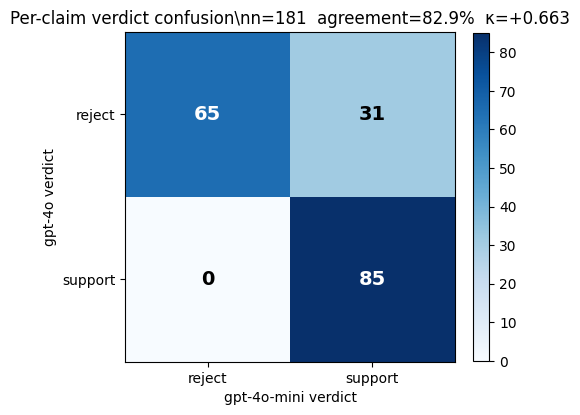

wrote /Users/hemakollipara/Desktop/ragcore/evaluation/results/judge_comparison_confusion_2026-06-02.png


In [11]:
import matplotlib.pyplot as plt

# Plot 1: 2x2 confusion matrix between the two judges
cm = np.array([
    [
        int(((df["gpt_4o"] == 0) & (df["gpt_4o_mini"] == 0)).sum()),
        int(((df["gpt_4o"] == 0) & (df["gpt_4o_mini"] == 1)).sum()),
    ],
    [
        int(((df["gpt_4o"] == 1) & (df["gpt_4o_mini"] == 0)).sum()),
        int(((df["gpt_4o"] == 1) & (df["gpt_4o_mini"] == 1)).sum()),
    ],
])
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["reject", "support"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["reject", "support"])
ax.set_xlabel("gpt-4o-mini verdict")
ax.set_ylabel("gpt-4o verdict")
ax.set_title(f"Per-claim verdict confusion\\nn={cm.sum()}  agreement={cm.trace()/cm.sum()*100:.1f}%  κ={kappa:+.3f}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
p_conf = PLOTS_DIR / "judge_comparison_confusion_2026-06-02.png"
plt.savefig(p_conf, dpi=130)
plt.show()
print("wrote", p_conf)

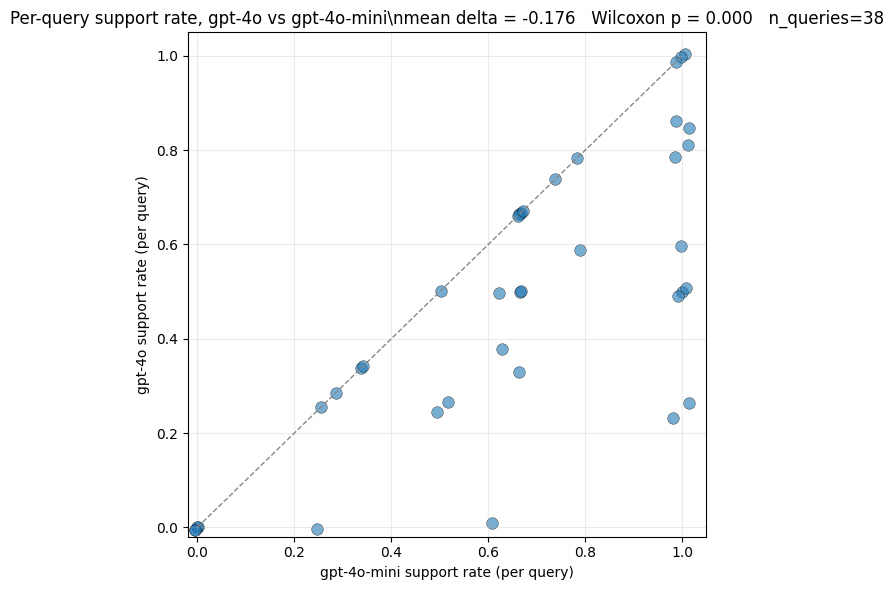

wrote /Users/hemakollipara/Desktop/ragcore/evaluation/results/judge_comparison_support_rate_2026-06-02.png


In [12]:
# Plot 2: per-query support rate — gpt-4o vs gpt-4o-mini
fig, ax = plt.subplots(figsize=(6, 6))
jitter = np.random.RandomState(7).normal(0, 0.008, size=len(per_query))
ax.scatter(per_query["rate_mini"] + jitter,
           per_query["rate_4o"] + jitter,
           s=70, alpha=0.6, edgecolors="k", linewidths=0.4)
ax.plot([0, 1], [0, 1], color="#888", linestyle="--", linewidth=1)
ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("gpt-4o-mini support rate (per query)")
ax.set_ylabel("gpt-4o support rate (per query)")
ax.set_title(
    f"Per-query support rate, gpt-4o vs gpt-4o-mini\\n"
    f"mean delta = {mean_delta:+.3f}   Wilcoxon p = {w_p:.3f}   n_queries={len(per_query)}"
)
ax.grid(alpha=0.25)
plt.tight_layout()
p_scatter = PLOTS_DIR / "judge_comparison_support_rate_2026-06-02.png"
plt.savefig(p_scatter, dpi=130)
plt.show()
print("wrote", p_scatter)

### 6. Qualitative disagreement table

Up to 10 disagreement cases with the claim text, a context excerpt, both judges' verdicts and reason/evidence, and (as a third reference point only — not ground truth) the per-query RAGAS faithfulness from the original 5-05 run.

In [13]:
# RAGAS faithfulness comes from the source run and is a per-query score, not
# per-claim. We join it on query_id and surface it as a third reference signal.
ragas_by_qid = {f["query_id"]: f["stored_ragas_faithfulness"] for f in frozen}
context_by_qid = {f["query_id"]: f["context_str"] for f in frozen}

dis = df[df["gpt_4o"] != df["gpt_4o_mini"]].copy()
dis["ragas_5_05"] = dis["query_id"].map(ragas_by_qid)
dis = dis.sort_values(["query_id", "claim_index"]).head(10)

rows = []
for _, r in dis.iterrows():
    ctx = context_by_qid.get(r["query_id"], "")
    excerpt = (ctx[:280] + "...") if len(ctx) > 280 else ctx
    rows.append({
        "query_id": r["query_id"],
        "claim": r["claim"],
        "context_excerpt": excerpt,
        "gpt-4o": "SUPP" if r["gpt_4o"] == 1 else "reject",
        "gpt-4o reason": r["gpt_4o_evidence"][:160],
        "gpt-4o-mini": "SUPP" if r["gpt_4o_mini"] == 1 else "reject",
        "mini reason": r["mini_evidence"][:160],
        "ragas (5-05, per-query)": r["ragas_5_05"],
    })

qual_df = pd.DataFrame(rows)
print(f"showing {len(qual_df)} of {(df['gpt_4o'] != df['gpt_4o_mini']).sum()} disagreement rows")
qual_df

showing 10 of 31 disagreement rows


,query_id,claim,context_excerpt,gpt-4o,gpt-4o reason,gpt-4o-mini,mini reason,"ragas (5-05, per-query)"
0,10385,You can start saving with a small amount like ...,Start as soon as you can and make your saving ...,reject,,SUPP,Start with whatever you feel comfortable with ...,0.8333
1,10595,Buying an inverse ETF does not yield the same ...,"""The most fundamental answer is that when you ...",reject,,SUPP,The most fundamental answer is that when you s...,0.6667
2,10595,The ETF may experience a net gain over a period.,"""The most fundamental answer is that when you ...",reject,,SUPP,the next day it moves up 10% (to a price of $1...,0.6667
3,1610,You can withdraw your contributions from a Rot...,Lets assume you put the max of 5000 per year i...,reject,,SUPP,,0.8500
4,1610,A Solo 401(k) can provide tax advantages.,Lets assume you put the max of 5000 per year i...,reject,,SUPP,"In 2017, this allows you to contribute up to $...",0.8500
5,1668,CurrencyFair can be used to send money from Eu...,The website http://currencyfair.com/ provides ...,reject,,SUPP,The website http://currencyfair.com/ provides ...,0.4000
6,1762,This can be set up using sub-accounts with var...,"Nowadays, all checks you write will not be sen...",reject,,SUPP,"talk to local banks about a business account, ...",0.7500
7,2147,It might be beneficial to explore rent-to-own ...,Never buy a house unless you really want to bu...,reject,,SUPP,"If you want to buy a house, it is very unlikel...",0.8000
8,2335,"You can give each of your children $28,000 on ...","In other words, if you give each of your chil...",reject,,SUPP,"$14,000 on or after January 1, 2013, the annua...",0.6667
9,3393,It is important for contractors to report the ...,"But if you want to calculate taxes yourself, a...",reject,,SUPP,the company isn't going to calculate or withho...,0.5000


## Summary card

In [14]:
summary = {
    "queries": n_queries,
    "claims": n_claims,
    "per_claim_agreement_pct": round(agreement_rate * 100, 1),
    "cohen_kappa": round(kappa, 3),
    "mean_support_rate_gpt_4o": round(mean_4o, 3),
    "mean_support_rate_gpt_4o_mini": round(mean_mini, 3),
    "mean_delta_4o_minus_mini": round(mean_delta, 3),
    "wilcoxon_p": (None if pd.isna(w_p) else round(float(w_p), 4)),
    "disagreement_4o_supp_mini_reject": a,
    "disagreement_4o_reject_mini_supp": b,
    "cost_per_100_claims_usd_gpt_4o": stats["gpt-4o"]["cost_per_100_claims_usd"],
    "cost_per_100_claims_usd_gpt_4o_mini": stats["gpt-4o-mini"]["cost_per_100_claims_usd"],
    "mean_latency_ms_gpt_4o": stats["gpt-4o"]["mean_latency_ms"],
    "mean_latency_ms_gpt_4o_mini": stats["gpt-4o-mini"]["mean_latency_ms"],
}
print(json.dumps(summary, indent=2))

{
  "queries": 38,
  "claims": 181,
  "per_claim_agreement_pct": 82.9,
  "cohen_kappa": 0.663,
  "mean_support_rate_gpt_4o": 0.477,
  "mean_support_rate_gpt_4o_mini": 0.653,
  "mean_delta_4o_minus_mini": -0.176,
  "wilcoxon_p": 0.0001,
  "disagreement_4o_supp_mini_reject": 0,
  "disagreement_4o_reject_mini_supp": 31,
  "cost_per_100_claims_usd_gpt_4o": 0.1775,
  "cost_per_100_claims_usd_gpt_4o_mini": 0.0058,
  "mean_latency_ms_gpt_4o": 681.1,
  "mean_latency_ms_gpt_4o_mini": 930.8
}


## Writeup

### Findings

**Lead finding — one-directional disagreement.** Of the 31 disagreement claims, **all 31 are "gpt-4o rejects, gpt-4o-mini supports"; 0 go the other way.** The cheap judge never rejects a claim that the expensive judge supports on this corpus. The substitution risk is one-directional: gpt-4o-mini systematically over-accepts relative to gpt-4o. This is the strongest signal in the comparison and the one that most directly informs the "can we substitute the cheap judge" question.

**Same picture, five framings.** Per-claim agreement (150/181 = **82.9%**), Cohen's κ (**+0.663**), mean per-query support-rate delta (**−0.176**), Wilcoxon signed-rank p (**0.0001**) on the 38-query paired sample, and the **0/31** asymmetry are **five views of one underlying confusion matrix**. They are not five independent corroborations — they are the same 181-row table re-summarized along different axes. The lead finding above is the most informative summary; the others are decorations on it.

### Token load and cost framing

**Measured tokens (from the OpenAI usage objects on each call — real measurements, not derivations):**

| model | total input tokens | total output tokens |
|---|---:|---:|
| gpt-4o | 49,885 | 4,784 |
| gpt-4o-mini | 49,885 | 5,032 |

**Input token load is identical between the two judges by construction.** Both judges saw the same 181 frozen claims paired with the same retrieved contexts and the same production prompt template. Output token counts differ slightly because the two models emit different verdict/evidence shapes. Any cost differential between the two judges is therefore **purely a function of the rate ratio at billing time**, not an empirical result of this run.

**Cost is rate-dependent; not reported as a measured total here.** The notebook's pricing cell encodes assumed rates (gpt-4o $5.00/$15.00 per 1M input/output, gpt-4o-mini $0.15/$0.60 per 1M input/output) and computes a derived dollar number from `tokens × those rates`. The captured artifact contains **no independent billing measurement** — only the token counts above. The gpt-4o launch-price assumption is known to be stale at 2026-06-03; gpt-4o has been price-reduced since launch while gpt-4o-mini has not, so the rate ratio is no longer the launch-time ~30×. **TODO — verify current gpt-4o and gpt-4o-mini per-1M input/output rates against the OpenAI dashboard, update the pricing cell, then re-run only the cost cell (pure pandas math, no API calls) to obtain a current cost differential.** Do not quote a measured dollar total or a ratio from this notebook until the rates have been refreshed; the underlying token counts above remain valid regardless.

### Validity checks

These audits protect the findings above; they are not themselves findings.

- **Production `_verify_claim` reused via injected shim — no reimplementation.** The replay loop calls `verifier._verify_claim(claim, context, shim)` on a stock `SelfRAGGenerator` imported from `generation.advanced_generation`. The shim is transport-only; the production prompt template, 3000-char context truncation, markdown-fence stripping, positive-whitelist support detection, and fail-closed exception handler all run from the production module. The only thing varied between the two replays is the model name passed to `AsyncOpenAI.chat.completions.create`.
- **Parse integrity: 0/181 fail-closed defaults per judge.** Replaying all 362 captured raw responses through the real `_strip_markdown_fences` + `json.loads` path classified every single one as `a_dict_*` (parsed to a dict). No fail-closed `(False, "")` defaults were silently entering the disagreement count. The 31 gpt-4o rejections in the disagreement set are all model-emitted `{"supported": false, ...}` JSON verdicts.
- **Dropped-query baseline clean: 12/12 zero-claim source queries.** The 38-query analysis set comes from filtering 50 → 38 in the replay loop. Each of the 12 dropped queries had `verified_claims == []` AND `unsupported_claims == []` in the 2026-05-05 source JSON — i.e. they produced no claims at all from the gpt-4o-mini extractor in the original Self-RAG run. None were silently lost from the replay; the 181 frozen claims is the full population available from the source artifact.

### Honesty boundaries

These bound what the findings above can be quoted as. They are unchanged from the original writeup.

- **Not "more accurate."** There are no faithfulness gold labels in this dataset. FiQA labels are document-level retrieval relevance only, not per-claim faithfulness. The 0-vs-31 asymmetry tells us the cheap judge over-accepts *relative to* the expensive judge; it does not tell us either judge is right.
- **Not "good enough."** That is a judgment call about an unobserved variable (true claim faithfulness), and we have no measurement of it.
- **Agreement is not vindication.** Both judges agree on 150/181 claims; under no-gold-label conditions this is consistent with both being right, both being wrong the same way, or sharing a bias from common training data.
- **Frozen claims are extractor-conditioned.** The 181 claims were extracted by gpt-4o-mini in the 2026-05-05 Self-RAG run. This experiment measures *given that decomposition, how do the two judges verify it*. A separate experiment with different claim sets per judge would measure something different — extractor-judge interaction — and would not yield well-defined per-claim agreement or κ at all.
- **Single-pass caveat.** Both judges run at temperature=0, but OpenAI temp=0 is not fully deterministic across calls. Within-judge variance is not characterized here; a repeated-run variant is a possible follow-on but is intentionally out of scope.
- **Latency — non-robust single-pass observation, not a finding.** Mean per-call latency was 681 ms for gpt-4o and 931 ms for gpt-4o-mini in this single pass (n=181 per model, sequential). Both judges' calls went through the same client to the same provider over the same network conditions, but a single pass is not enough to claim a robust latency ordering — provider-side latency varies with load and with model-version-specific routing. Do not quote latency as a reason to prefer one judge over the other on the strength of this run alone.
- **Possible follow-on, not included here.** Hand-annotating the 31 disagreement claims would convert them into a labeled mini-evalset and enable a per-judge accuracy claim against that small set. That is a sequenced decision — out of scope for this notebook.